In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import datetime as dt

import os

from dotenv import load_dotenv

import mne
from mne_bids import BIDSPath

In [2]:
# Set constants and paths

load_dotenv()  # Load environment variables from .env file
ROOT = os.getenv("ROOT")

RAW_DATA = ROOT
DERIVATIVES = f"{ROOT}/derivatives"
PREPROC_DATA = f"{DERIVATIVES}/preprocessed"
EPOCHED_DATA = f"{DERIVATIVES}/epoched"

# Create directories if they don't exist
os.makedirs(DERIVATIVES, exist_ok=True)
os.makedirs(PREPROC_DATA, exist_ok=True)
os.makedirs(EPOCHED_DATA, exist_ok=True)

N_JOBS = -1

SUBJECTS = [f"{i:03d}" for i in range(1, 25)]  # '001' through '024'
SESSIONS = ["01", "02", "03"]

In [ ]:
# there is a glitch where if a subj answered 0 for any question it is not recorded
# as a result, if the last column has a "-1", it means that subject has missing data
# based on this, I want to calculate the percent of readable epochs


# dictionary of all epoch metadata

all_subjs_epochs = []

for subject in SUBJECTS:
    percent = 1.0
    for session in SESSIONS:
        try:
            bp = BIDSPath(
                subject=subject,
                session=session,
                task="meditation",
                description="epo",  # Identifies these as epochs
                suffix="eeg",  # Official BIDS suffix
                datatype="eeg",
                root=EPOCHED_DATA,  # Point to your derivatives folder
                extension=".fif",
                check=False,  # Allows us to define custom 'desc' tags
            )
            epochs = mne.read_epochs(bp.fpath, preload=False, verbose="ERROR")
            all_subjs_epochs.append(epochs)

            print(f"Subject {subject}, Session {session}: {len(epochs)} epochs loaded.")
        except Exception as e:
            continue

In [ ]:
# epochs that arent missing any probe data

num_total_epochs = 0
num_mw_epochs = 0
num_meditation_epochs = 0
num_epochs_missing_probes = 0
num_inconclusive_epochs = 0

for epochs in all_subjs_epochs:
    num_total_epochs += len(epochs)

    epochs_clean = epochs["meditation_depth != -1 and mw_depth != -1 and fatigue != -1"]
    epochs_missing_probes = epochs[
        "meditation_depth == -1 or mw_depth == -1 or fatigue == -1"
    ]

    mw_epochs = epochs_clean["mw_depth > meditation_depth"]
    meditation_epochs = epochs_clean["meditation_depth > mw_depth"]
    inconclusive_epochs = epochs_clean[
        "meditation_depth == mw_depth"
    ]  # have to discard these epochs. can't use for analysis or as labels bec it doesnt differentiate mw from meditation

    num_epochs_missing_probes += len(epochs_missing_probes)
    num_inconclusive_epochs += len(inconclusive_epochs)

    num_mw_epochs += len(mw_epochs)
    num_meditation_epochs += len(meditation_epochs)

print(
    f"Epochs discarded due to inconclusive probe data (mw_depth = meditation_depth): {num_inconclusive_epochs}"
)
print(f"Epochs missing probe data: {num_epochs_missing_probes}")
print(
    f"Epochs discarded (total): {num_epochs_missing_probes + num_inconclusive_epochs}"
)
print(f"Epochs labeled as mind wandering: {num_mw_epochs}")
print(f"Epochs labeled as meditation: {num_meditation_epochs}")
print(f"Total epochs: {num_total_epochs}")

         Meditation %  Mind Wandering %
subject                                
1           48.387097         51.612903
2           63.333333         36.666667
3           64.000000         36.000000
4           86.956522         13.043478
5           72.972973         27.027027
6           66.666667         33.333333
7           92.000000          8.000000
8           85.000000         15.000000
9           98.387097          1.612903
10          73.684211         26.315789
11          89.130435         10.869565
12          55.555556         44.444444
13          33.333333         66.666667
14          29.411765         70.588235
15          52.631579         47.368421
16          30.000000         70.000000
17         100.000000               NaN
18                NaN        100.000000
19          28.571429         71.428571
20          43.243243         56.756757
21          20.833333         79.166667
22          37.500000         62.500000
23          51.724138         48.275862


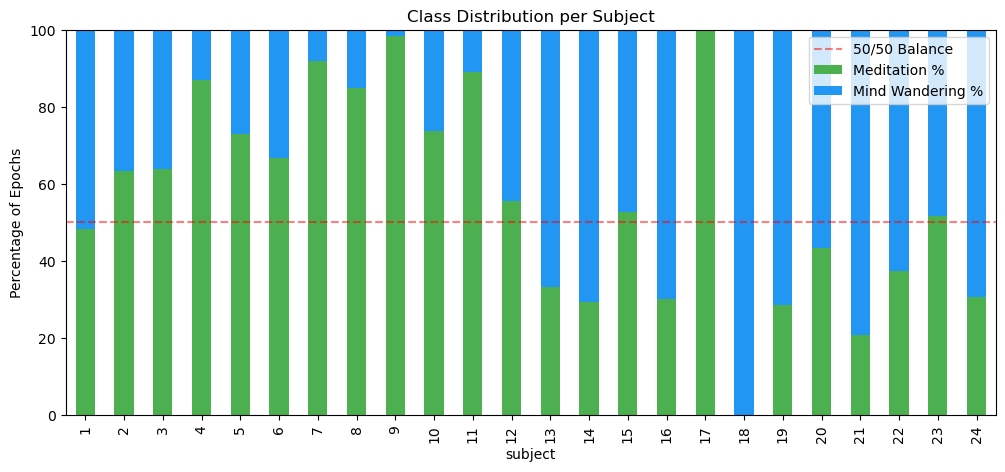

In [1]:
# class distribution per subject

import os
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from dotenv import load_dotenv


load_dotenv()  # Load environment variables from .env file
ROOT = os.getenv("ROOT")
RAW_DATA = ROOT
DERIVATIVES = f"{ROOT}derivatives"
DATA_PATH = f"{DERIVATIVES}/noica"
FEATURES_PATH = f"{DATA_PATH}/features"


class EEGDataset(Dataset):
    def __init__(self, raw_data):
        ## Clean and label data
        # Filter rows where mw_depth equals meditation_depth
        raw_data = raw_data[raw_data["mw_depth"] != raw_data["meditation_depth"]].copy()
        # Label data: is_mw variable is 1 for mind wandering, 0 for meditation
        raw_data["is_mw"] = (
            raw_data["mw_depth"] > raw_data["meditation_depth"]
        ).astype(int)

        self.raw_data = raw_data
        non_feature_cols = [
            "subject",
            "session",
            "channel",
            "epoch_idx",
            "is_mw",
            "mw_depth",
            "meditation_depth",
            "fatigue",
        ]
        feature_columns = [
            col for col in self.raw_data.columns if col not in non_feature_cols
        ]

        self.features = feature_columns


raw_data = pd.read_csv(
    f"{FEATURES_PATH}/combined_features/all_features_merged.tsv", sep="\t"
)
dataset = EEGDataset(raw_data=raw_data)

# Access the dataframe after labels were created in the class
df = dataset.raw_data

# Calculate percentages
# 0 = Meditation, 1 = Mind Wandering
balance = df.groupby("subject")["is_mw"].value_counts(normalize=True).unstack() * 100

# Rename for clarity
balance.columns = ["Meditation %", "Mind Wandering %"]
print(balance)


balance.plot(kind="bar", stacked=True, figsize=(12, 5), color=["#4CAF50", "#2196F3"])
plt.axhline(50, color="red", linestyle="--", alpha=0.5, label="50/50 Balance")
plt.title("Class Distribution per Subject")
plt.ylabel("Percentage of Epochs")
plt.legend(loc="upper right")
plt.show()